In [1]:
import control
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.signal

sns.set_style("whitegrid")

Ball & Beam: Digital PID Controller Design


Key MATLAB commands used in this tutorial are:

<http://www.mathworks.com/help/toolbox/control/ref/tf.html |tf|> ,

<http://www.mathworks.com/help/toolbox/control/ref/c2d.html |c2d|> ,

<http://www.mathworks.com/help/toolbox/control/ref/step.html |step|> ,

<http://www.mathworks.com/help/techdoc/ref/stairs.html |stairs|> ,

<http://www.mathworks.com/help/toolbox/control/ref/feedback.html |feedback|>


The open-loop transfer function of the plant for the ball and beam

experiment is given below:


$$
P(s) = \frac{R(s)}{\Theta(s)} =

-\frac{mgd}{L\left(\frac{J}{R^2}+m\right)}\frac{1}{s^2} \qquad [

\frac{m}{rad} ]
 $$


The design criteria for this problem are:


* Settling time less than 3 seconds

* Overshoot less than 5% 


To see the derivation of the equations for this problem refer to the 

< ?example=BallBeam&section=SystemModeling Ball & Beam: System Modeling> page.


Digital PID controller


If you refer to any of the PID control problem for continuous systems,

the PID transfer function was expressed as 


$$C(s) = K_p + \frac{K_i}{s} + K_d s = \frac{K_d s^2 + K_p s + K_i}{s}$$


As you noticed the above transfer function was written in terms of $s$. For

the digital PID control, we use the following transfer function in terms of $z$. 


$$C(z) = K_p + K_i\frac{z}{z-1}+K_d\frac{z-1}{z} = \frac{(K_p+K_i+K_d)z^2-(K_p+2K_d)z+K_d}{z^2-z}$$


Discrete Transfer Function


The first thing to do here is to convert the above continuous system

transfer function to an equivalent discrete transfer function. To do this, 

we will use the MATLAB function |c2d|. To use |c2d|, we need to specify three 

arguments: system, sampling time (|Ts|), and the |'method'|. You should already

be familiar with how to create a system from numerator and denominator matrices. 

The sampling time should be smaller than $1/(30\omega_{bw})$ sec, where $\omega_{bw}$ is the 

closed-loop bandwidth frequency. The method we will use is the zero-order 

hold (|'zoh'|). Assuming that the closed-loop bandwidth frequency is around 

1 rad/sec, let the sampling time be 1/50 sec/sample. Now we are ready to 

use |c2d|. Enter the following commands to an m-file. Running this m-file 

in the MATLAB command window gives you the following matrices.  


In [2]:

m = 0.111
R = 0.015
g = -9.8
L = 1.0
d = 0.03
J = 9.99e-6
s = control.tf('s')
P_ball = -m*g*d/L/(J/R**2+m)/s**2

Ts = 1/50
ball_d = control.c2d(P_ball, Ts, method='zoh')


Open-loop response


Now we will observe the ball's response to a step input of 0.25 m. To do

this, enter the following commands into a new m-file and run it in the 

command window. You should see the following response. 


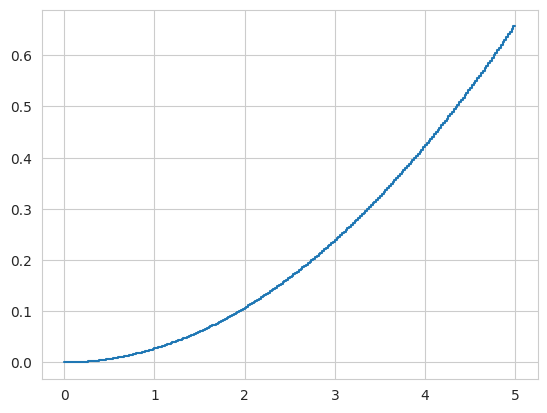

In [3]:

numDz = 0.0001*np.array([0.42, 0.42])
denDz = np.array([1, -2, 1])
Ts = 1/50
ball_d = control.tf(numDz, denDz, dt=Ts)

T, yout = control.step_response(0.25*ball_d, 5)
plt.step(T, yout)

From this plot, it is clear that the open-loop system is unstable causing

the ball to roll off the end of the beam. 


Proportional control


Now we will add proportional control ($K_p$) to the system and obtain the

closed-loop system response. For now let $K_p$ equal 100 and see what happens 

to the response. Enter the following commands into a new m-file and run 

it in the command window. 


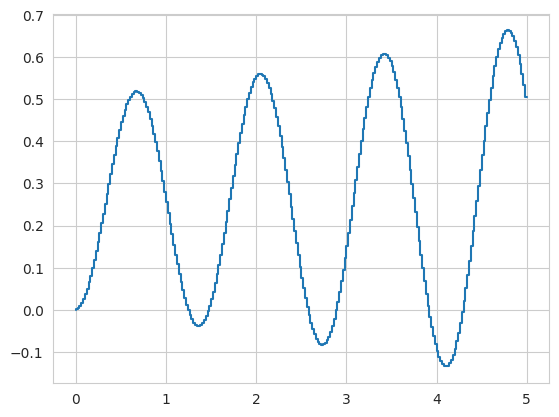

In [4]:

Ts = 1/50
# Create discrete transfer function: 0.0001*(0.42*z + 0.42)/(z**2 - 2*z + 1)
# Numerator: 0.000042*z + 0.000042, Denominator: z^2 - 2*z + 1
numDz = np.array([0.000042, 0.000042])  # coefficients of z^1, z^0
denDz = np.array([1, -2, 1])  # coefficients of z^2, z^1, z^0
dP_ball = control.tf(numDz, denDz, dt=Ts)

Kp = 100
sys_cl = control.feedback(Kp*dP_ball, 1)

T, yout = control.step_response(0.25*sys_cl, 5)
plt.step(T, yout)

As you can see, the addition of proportional control does not make the

system stable. You may try to increase the proportional gain ($K_p$) and 

confirm that the system remains unstable. 


Proportional-derivative control


Now we will add a derivative term to the controller. Keep the

proportional gain ($K_p$) equal to 100, and let the derivative gain ($K_d$) 

equal to 10. Copy the following code to an new m-file and run it to view 

the system response. 


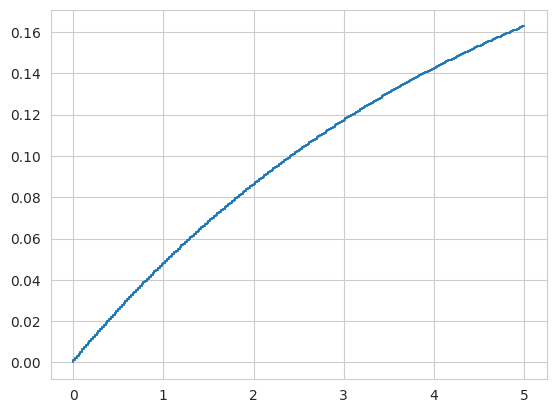

In [5]:

Ts = 1/50
# Create discrete transfer function: 0.0001*(0.42*z + 0.42)/(z**2 - 2*z + 1)
numDz = np.array([0.000042, 0.000042])
denDz = np.array([1, -2, 1])
dP_ball = control.tf(numDz, denDz, dt=Ts)

Kp = 100
Kd = 10

# Create controller: C = ((Kp+Kd)*z^2 - (Kp+2*Kd)*z + Kd)/(z^2 + z)
# Numerator: (Kp+Kd)*z^2 - (Kp+2*Kd)*z + Kd
# Denominator: z^2 + z = z^2 + z + 0
numC = np.array([Kp+Kd, -(Kp+2*Kd), Kd])  # coefficients of z^2, z^1, z^0
denC = np.array([1, 1, 0])  # coefficients of z^2, z^1, z^0
C = control.tf(numC, denC, dt=Ts)

sys_cl = control.feedback(C*dP_ball, 1)

T, yout = control.step_response(0.25*sys_cl, 5)
plt.step(T, yout)

Now the system is stable, but the rise time is too long. From the PID

Tutorial page, we see that the increasing the proportional gain ($K_p$) will 

decrease the rise time. Let's increase the proportional gain ($K_p$) to 1000 

and see what happens. Change $K_p$ in the above m-file from 100 to 1000 and 

rerun it in the command window. You should see the following step response. 


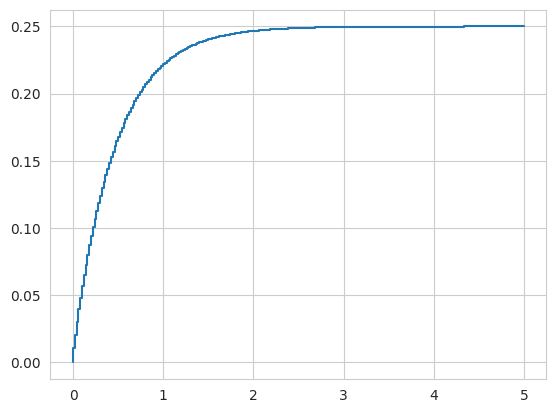

In [6]:

Kp = 1000
Kd = 10

# Create controller: C = ((Kp+Kd)*z^2 - (Kp+2*Kd)*z + Kd)/(z^2 + z)
numC = np.array([Kp+Kd, -(Kp+2*Kd), Kd])
denC = np.array([1, 1, 0])
C = control.tf(numC, denC, dt=Ts)

sys_cl = control.feedback(C*dP_ball, 1)

T, yout = control.step_response(0.25*sys_cl, 5)
plt.step(T, yout)

As you can see, all of the design requirements are satisfied. For this

particular problem, no implementation of an integral control was needed. 

But remember there is more than one solution for a control problem. For 

practice, you may try different P, I and D combinations to obtain a 

satisfactory response.